# This notebook is to test the actual NumPy-based and cuPyNumeric-based implementations of ExactBO

In [1]:
import tamubo.exactbo as ebo
import tamubo.utils as utils
import tamubo.acquisition_functions as acqfun
import cupynumeric as cp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

## 1 -  Check Expected Improvement

In [4]:
cpmu = cp.array([0.1, 0.2, 0.3])
cpsigma = cp.array([0.1, 0.2, 0.3])

npmu = np.array([0.1, 0.2, 0.3])
npsigma = np.array([0.1, 0.2, 0.3])

ymin = 0.0

cpei = acqfun.expected_improvement(cpmu, cpsigma, ymin)
#npei = ebo.expected_improvement(npmu, npsigma, ymin)

In [5]:
cpei

array([0.00833155, 0.01666309, 0.02499464])

In [6]:
tempcpei = acqfun.expected_improvement(cpmu, cpsigma, ymin, backend="cupynumeric")
tempnpei = acqfun.expected_improvement(npmu, npsigma, ymin, backend="numpy")

In [7]:
tempcpei, tempnpei

(array([0.00833155, 0.01666309, 0.02499464]),
 array([0.00833155, 0.01666309, 0.02499464]))

## 2 -  Check Backend

In [8]:
utils.resolve_backend()

BackendInfo(requested='auto', selected='cupynumeric', cupynumeric_available=True)

## 3 - Check Partitioning

In [13]:
bounds_L = np.array([[0.0, 0.0], 
                     [0.4, 0.7]])

bounds_U = np.array([[0.3, 0.9], 
                     [1.0, 1.0]])

active_boxes_mask = np.array([True, True])

w = np.array([3, 1])
n = 2
d = 2

bounds_L_np, bounds_U_np = ebo.split_boxes(bounds_L, bounds_U, active_boxes_mask, w, n, d, backend="numpy")

NameError: name 'ebo' is not defined

In [3]:
bounds_L_cp, bounds_U_cp = ebo.split_boxes(bounds_L, bounds_U, active_boxes_mask, w, n, d)

In [4]:
def plot_rectangles(bounds_L, bounds_U, pad=0.01):
    bounds_L = np.asarray(bounds_L)
    bounds_U = np.asarray(bounds_U)
    assert bounds_L.shape == bounds_U.shape and bounds_L.shape[1] == 2

    widths = bounds_U[:, 0] - bounds_L[:, 0]
    heights = bounds_U[:, 1] - bounds_L[:, 1]

    inset_ll = bounds_L + pad
    inset_w = np.maximum(widths - 2 * pad, 0)
    inset_h = np.maximum(heights - 2 * pad, 0)

    fig, ax = plt.subplots()
    for (x, y), w, h in zip(inset_ll, inset_w, inset_h):
        ax.add_patch(Rectangle((x, y), w, h,
                               fill=False,
                               linewidth=2.0,
                               edgecolor='C0'))
    ax.set_aspect('equal', adjustable='box')
    ax.autoscale_view()
    plt.show()

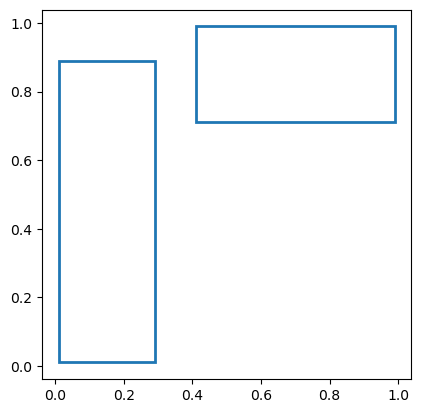

In [5]:
plot_rectangles(bounds_L, bounds_U)

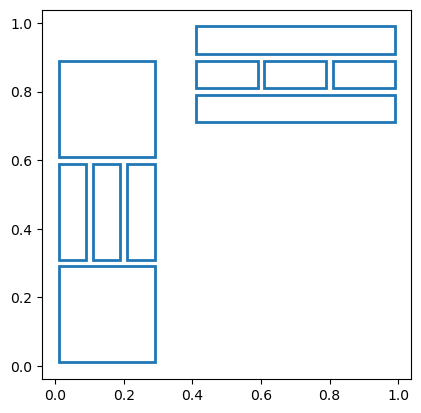

In [6]:
plot_rectangles(bounds_L_np, bounds_U_np)

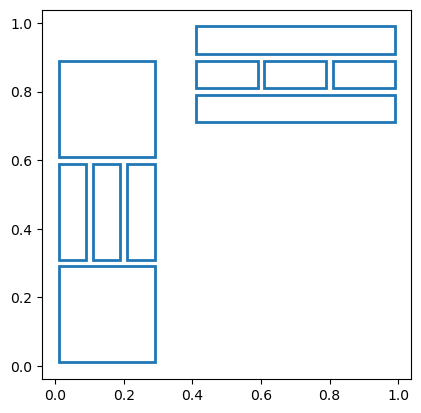

In [7]:
plot_rectangles(bounds_L_cp,bounds_U_cp)

In [78]:
d = 3
nt = 2
bounds_L = cp.array([[0.0, 0.0, 0.0], 
                     [0.4, 0.7, 0.1]])
bounds_U = cp.array([[0.3, 0.9, 0.6], 
                     [1.0, 1.0, 1.0]])

bounds_L_out = cp.repeat(bounds_L, repeats=2 * d + 1, axis=0)
bounds_U_out = cp.repeat(bounds_U, repeats=2 * d + 1, axis=0)

boxes_width = cp.repeat(cp.subtract(bounds_U, bounds_L), repeats=2 * d + 1, axis=0)

boxes_split_order = cp.argsort(boxes_width, axis=1)

In [79]:
boxes_width

array([[0.3, 0.9, 0.6],
       [0.3, 0.9, 0.6],
       [0.3, 0.9, 0.6],
       [0.3, 0.9, 0.6],
       [0.3, 0.9, 0.6],
       [0.3, 0.9, 0.6],
       [0.3, 0.9, 0.6],
       [0.6, 0.3, 0.9],
       [0.6, 0.3, 0.9],
       [0.6, 0.3, 0.9],
       [0.6, 0.3, 0.9],
       [0.6, 0.3, 0.9],
       [0.6, 0.3, 0.9],
       [0.6, 0.3, 0.9]])

In [80]:
boxes_split_order

array([[0, 2, 1],
       [0, 2, 1],
       [0, 2, 1],
       [0, 2, 1],
       [0, 2, 1],
       [0, 2, 1],
       [0, 2, 1],
       [1, 0, 2],
       [1, 0, 2],
       [1, 0, 2],
       [1, 0, 2],
       [1, 0, 2],
       [1, 0, 2],
       [1, 0, 2]])

In [81]:
dd = 0

mask_L = cp.ones(2 * d + 1, dtype=bool)
mask_L[: 2 * (d - dd - 1)] = False
mask_L[2 * (d - dd - 1)] = False
mask_L_out = cp.tile(mask_L, nt)

mask_U = cp.ones(2 * d + 1, dtype=bool)
mask_U[: 2 * (d - dd - 1)] = False
mask_U[2 * (d - dd - 1) + 1] = False
mask_U_out = cp.tile(mask_U, nt)

In [82]:
mask_L.shape, mask_L_out.shape

((7,), (14,))

In [83]:
mask_L, mask_U

(array([False, False, False, False, False,  True,  True]),
 array([False, False, False, False,  True, False,  True]))

In [84]:
mask_order = boxes_split_order == dd
mask_order

array([[ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [False,  True, False],
       [False,  True, False],
       [False,  True, False],
       [False,  True, False],
       [False,  True, False],
       [False,  True, False],
       [False,  True, False]])

In [85]:
l = bounds_L_out[mask_order] # (nt*(2*d+1),)
u = bounds_U_out[mask_order] # (nt*(2*d+1),)
w = boxes_width[mask_order]

lb = l + w / 3
ub = u - w / 3

l, u, w, lb, ub

(array([0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.7, 0.7, 0.7, 0.7, 0.7, 0.7,
        0.7]),
 array([0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 1. , 1. , 1. , 1. , 1. , 1. ,
        1. ]),
 array([0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3,
        0.3]),
 array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8,
        0.8]),
 array([0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9,
        0.9]))

In [86]:
mask_subs = cp.ones(2 * (dd + 1), dtype=bool)
mask_subs[0] = False
mask_subs_out = cp.tile(mask_subs, nt) # (nt*2*(dd+1),)
mask_subs_out

array([False,  True, False,  True])

In [87]:
rows_mask_order, cols_mask_order = cp.where(mask_order)
rows_mask_order, cols_mask_order

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),
 array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1]))

In [88]:
rows_l = rows_mask_order[mask_L_out]
cols_l = cols_mask_order[mask_L_out]
vals_l = lb[mask_L_out]
rows_u = rows_mask_order[mask_U_out]
cols_u = cols_mask_order[mask_U_out]
vals_u = ub[mask_U_out]

print(rows_l, cols_l, vals_l)
print(rows_u, cols_u, vals_u)

[ 5  6 12 13] [0 0 1 1] [0.1 0.1 0.8 0.8]
[ 4  6 11 13] [0 0 1 1] [0.2 0.2 0.9 0.9]


In [90]:
bounds_L_out[rows_l[mask_subs_out], cols_l[mask_subs_out]] = vals_l[mask_subs_out]
bounds_L_out[rows_l[~mask_subs_out], cols_l[~mask_subs_out]] = vals_u[~mask_subs_out]
bounds_U_out[rows_u[~mask_subs_out], cols_u[~mask_subs_out]] = vals_l[~mask_subs_out]
bounds_U_out[rows_u[mask_subs_out], cols_u[mask_subs_out]] = vals_u[mask_subs_out]

In [92]:
dd = 1

mask_L = cp.ones(2 * d + 1, dtype=bool)
mask_L[: 2 * (d - dd - 1)] = False
mask_L[2 * (d - dd - 1)] = False
mask_L_out = cp.tile(mask_L, nt)

mask_U = cp.ones(2 * d + 1, dtype=bool)
mask_U[: 2 * (d - dd - 1)] = False
mask_U[2 * (d - dd - 1) + 1] = False
mask_U_out = cp.tile(mask_U, nt)

In [93]:
mask_order = boxes_split_order == dd

In [94]:
l = bounds_L_out[mask_order] # (nt*(2*d+1),)
u = bounds_U_out[mask_order] # (nt*(2*d+1),)
w = boxes_width[mask_order]

lb = l + w / 3
ub = u - w / 3

l, u, w, lb, ub

(array([0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,
        0.4]),
 array([0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 1. , 1. , 1. , 1. , 1. , 1. ,
        1. ]),
 array([0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6,
        0.6]),
 array([0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6,
        0.6]),
 array([0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8,
        0.8]))

In [95]:
mask_subs = cp.ones(2 * (dd + 1), dtype=bool)
mask_subs[0] = False
mask_subs_out = cp.tile(mask_subs, nt) # (nt*2*(dd+1),)
mask_subs_out

array([False,  True,  True,  True, False,  True,  True,  True])

In [96]:
rows_mask_order, cols_mask_order = cp.where(mask_order)

In [97]:
rows_l = rows_mask_order[mask_L_out]
cols_l = cols_mask_order[mask_L_out]
vals_l = lb[mask_L_out]
rows_u = rows_mask_order[mask_U_out]
cols_u = cols_mask_order[mask_U_out]
vals_u = ub[mask_U_out]

print(rows_l, cols_l, vals_l)
print(rows_u, cols_u, vals_u)

[ 3  4  5  6 10 11 12 13] [2 2 2 2 0 0 0 0] [0.2 0.2 0.2 0.2 0.6 0.6 0.6 0.6]
[ 2  4  5  6  9 11 12 13] [2 2 2 2 0 0 0 0] [0.4 0.4 0.4 0.4 0.8 0.8 0.8 0.8]


In [98]:
bounds_L_out[rows_l[mask_subs_out], cols_l[mask_subs_out]] = vals_l[mask_subs_out]
bounds_L_out[rows_l[~mask_subs_out], cols_l[~mask_subs_out]] = vals_u[~mask_subs_out]
bounds_U_out[rows_u[~mask_subs_out], cols_u[~mask_subs_out]] = vals_l[~mask_subs_out]
bounds_U_out[rows_u[mask_subs_out], cols_u[mask_subs_out]] = vals_u[mask_subs_out]

In [100]:
dd = 2

mask_L = cp.ones(2 * d + 1, dtype=bool)
mask_L[: 2 * (d - dd - 1)] = False
mask_L[2 * (d - dd - 1)] = False
mask_L_out = cp.tile(mask_L, nt)

mask_U = cp.ones(2 * d + 1, dtype=bool)
mask_U[: 2 * (d - dd - 1)] = False
mask_U[2 * (d - dd - 1) + 1] = False
mask_U_out = cp.tile(mask_U, nt)

In [101]:
mask_order = boxes_split_order == dd

In [102]:
l = bounds_L_out[mask_order] # (nt*(2*d+1),)
u = bounds_U_out[mask_order] # (nt*(2*d+1),)
w = boxes_width[mask_order]

lb = l + w / 3
ub = u - w / 3

l, u, w, lb, ub

(array([0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
        0.1]),
 array([0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 1. , 1. , 1. , 1. , 1. , 1. ,
        1. ]),
 array([0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9,
        0.9]),
 array([0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,
        0.4]),
 array([0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7,
        0.7]))

In [103]:
mask_subs = cp.ones(2 * (dd + 1), dtype=bool)
mask_subs[0] = False
mask_subs_out = cp.tile(mask_subs, nt) # (nt*2*(dd+1),)
mask_subs_out

array([False,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True])

In [104]:
rows_mask_order, cols_mask_order = cp.where(mask_order)

In [105]:
rows_l = rows_mask_order[mask_L_out]
cols_l = cols_mask_order[mask_L_out]
vals_l = lb[mask_L_out]
rows_u = rows_mask_order[mask_U_out]
cols_u = cols_mask_order[mask_U_out]
vals_u = ub[mask_U_out]

print(rows_l, cols_l, vals_l)
print(rows_u, cols_u, vals_u)

[ 1  2  3  4  5  6  8  9 10 11 12 13] [1 1 1 1 1 1 2 2 2 2 2 2] [0.3 0.3 0.3 0.3 0.3 0.3 0.4 0.4 0.4 0.4 0.4 0.4]
[ 0  2  3  4  5  6  7  9 10 11 12 13] [1 1 1 1 1 1 2 2 2 2 2 2] [0.6 0.6 0.6 0.6 0.6 0.6 0.7 0.7 0.7 0.7 0.7 0.7]


In [106]:
bounds_L_out[rows_l[mask_subs_out], cols_l[mask_subs_out]] = vals_l[mask_subs_out]
bounds_L_out[rows_l[~mask_subs_out], cols_l[~mask_subs_out]] = vals_u[~mask_subs_out]
bounds_U_out[rows_u[~mask_subs_out], cols_u[~mask_subs_out]] = vals_l[~mask_subs_out]
bounds_U_out[rows_u[mask_subs_out], cols_u[mask_subs_out]] = vals_u[mask_subs_out]

In [89]:
# Before dd=0
bounds_L_out, bounds_U_out

(array([[0. , 0. , 0. ],
        [0. , 0. , 0. ],
        [0. , 0. , 0. ],
        [0. , 0. , 0. ],
        [0. , 0. , 0. ],
        [0. , 0. , 0. ],
        [0. , 0. , 0. ],
        [0.4, 0.7, 0.1],
        [0.4, 0.7, 0.1],
        [0.4, 0.7, 0.1],
        [0.4, 0.7, 0.1],
        [0.4, 0.7, 0.1],
        [0.4, 0.7, 0.1],
        [0.4, 0.7, 0.1]]),
 array([[0.3, 0.9, 0.6],
        [0.3, 0.9, 0.6],
        [0.3, 0.9, 0.6],
        [0.3, 0.9, 0.6],
        [0.3, 0.9, 0.6],
        [0.3, 0.9, 0.6],
        [0.3, 0.9, 0.6],
        [1. , 1. , 1. ],
        [1. , 1. , 1. ],
        [1. , 1. , 1. ],
        [1. , 1. , 1. ],
        [1. , 1. , 1. ],
        [1. , 1. , 1. ],
        [1. , 1. , 1. ]]))

In [91]:
# Before dd=1
bounds_L_out, bounds_U_out

(array([[0. , 0. , 0. ],
        [0. , 0. , 0. ],
        [0. , 0. , 0. ],
        [0. , 0. , 0. ],
        [0. , 0. , 0. ],
        [0.2, 0. , 0. ],
        [0.1, 0. , 0. ],
        [0.4, 0.7, 0.1],
        [0.4, 0.7, 0.1],
        [0.4, 0.7, 0.1],
        [0.4, 0.7, 0.1],
        [0.4, 0.7, 0.1],
        [0.4, 0.9, 0.1],
        [0.4, 0.8, 0.1]]),
 array([[0.3, 0.9, 0.6],
        [0.3, 0.9, 0.6],
        [0.3, 0.9, 0.6],
        [0.3, 0.9, 0.6],
        [0.1, 0.9, 0.6],
        [0.3, 0.9, 0.6],
        [0.2, 0.9, 0.6],
        [1. , 1. , 1. ],
        [1. , 1. , 1. ],
        [1. , 1. , 1. ],
        [1. , 1. , 1. ],
        [1. , 0.8, 1. ],
        [1. , 1. , 1. ],
        [1. , 0.9, 1. ]]))

In [99]:
# Before dd=2
bounds_L_out, bounds_U_out

(array([[0. , 0. , 0. ],
        [0. , 0. , 0. ],
        [0. , 0. , 0. ],
        [0. , 0. , 0.4],
        [0. , 0. , 0.2],
        [0.2, 0. , 0.2],
        [0.1, 0. , 0.2],
        [0.4, 0.7, 0.1],
        [0.4, 0.7, 0.1],
        [0.4, 0.7, 0.1],
        [0.8, 0.7, 0.1],
        [0.6, 0.7, 0.1],
        [0.6, 0.9, 0.1],
        [0.6, 0.8, 0.1]]),
 array([[0.3, 0.9, 0.6],
        [0.3, 0.9, 0.6],
        [0.3, 0.9, 0.2],
        [0.3, 0.9, 0.6],
        [0.1, 0.9, 0.4],
        [0.3, 0.9, 0.4],
        [0.2, 0.9, 0.4],
        [1. , 1. , 1. ],
        [1. , 1. , 1. ],
        [0.6, 1. , 1. ],
        [1. , 1. , 1. ],
        [0.8, 0.8, 1. ],
        [0.8, 1. , 1. ],
        [0.8, 0.9, 1. ]]))

In [107]:
# final
bounds_L_out, bounds_U_out

(array([[0. , 0. , 0. ],
        [0. , 0.6, 0. ],
        [0. , 0.3, 0. ],
        [0. , 0.3, 0.4],
        [0. , 0.3, 0.2],
        [0.2, 0.3, 0.2],
        [0.1, 0.3, 0.2],
        [0.4, 0.7, 0.1],
        [0.4, 0.7, 0.7],
        [0.4, 0.7, 0.4],
        [0.8, 0.7, 0.4],
        [0.6, 0.7, 0.4],
        [0.6, 0.9, 0.4],
        [0.6, 0.8, 0.4]]),
 array([[0.3, 0.3, 0.6],
        [0.3, 0.9, 0.6],
        [0.3, 0.6, 0.2],
        [0.3, 0.6, 0.6],
        [0.1, 0.6, 0.4],
        [0.3, 0.6, 0.4],
        [0.2, 0.6, 0.4],
        [1. , 1. , 0.4],
        [1. , 1. , 1. ],
        [0.6, 1. , 0.7],
        [1. , 1. , 0.7],
        [0.8, 0.8, 0.7],
        [0.8, 1. , 0.7],
        [0.8, 0.9, 0.7]]))

## 4 - Check bounds

### 4.1 - Native check

In [5]:
bounds_L = [[0.0, 0.0, 0.0],
            [0.4, 0.7, 0.1]]
bounds_U = [[0.3, 0.9, 0.6],
            [1.0, 1.0, 1.0]]
xi = [[0.1, 0.2, 0.3],
      [0.5, 0.5, 0.5],
      [0.9, 0.8, 0.7]]
n = 2
d = 3
sigma_f_2 = 0.01
length_scale = 0.5

In [7]:
K_lo_np, K_hi_np = ebo.rbf_k_bounds(bounds_L, bounds_U, xi[0], n, d, sigma_f_2, length_scale, backend="numpy")
K_lo_np, K_hi_np, type(K_lo_np), type(K_hi_np)

(array([0.00289384, 0.00020651]),
 array([0.01      , 0.00506617]),
 numpy.ndarray,
 numpy.ndarray)

In [9]:
K_lo_cp, K_hi_cp = ebo.rbf_k_bounds(bounds_L, bounds_U, xi[0], n, d, sigma_f_2, length_scale)
K_lo_cp, K_hi_cp, type(K_lo_cp), type(K_hi_cp)

(array([0.00289384, 0.00020651]),
 array([0.01      , 0.00506617]),
 cupynumeric._array.array.ndarray,
 cupynumeric._array.array.ndarray)

### 4.2 - Advanced check

In [3]:
# Define model
kernel = ConstantKernel(1.0, (1e-2, 1e3)) * RBF(length_scale=0.2, length_scale_bounds=(1e-2, 10.0)) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-10, 1e1))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)

# Define bounds
bounds = np.array([[0,1],[0,1]])

# Function to minimize
# f(x,y)= \alpha(x^2 + y^2) - \sum_{i=1}^3 A_i \exp \left( -\frac{(x - Cx_i)^2 + (y - Cy_i)^2}{B_i} \right) + D
def f(X):
    if len(X.shape) == 1:
        X = X.reshape(1,-1)
        
    x, y = X[:,0], X[:,1]

    # Parameters
    alpha = 0.1
    A  = np.array([4, 3, 2])
    B  = np.array([0.08, 0.05, 0.02])    # betas
    C  = np.array([[0.9, 0.3 ],      # centers (x1,y1)
                [0.1 , 0.8],
                [0.6 , 0.7 ]])
    D = 2
    
    # Compute function value
    val = alpha*(x**2 + y**2)
    for Ai, Bi, (xi, yi) in zip(A, B, C):
        r2 = (x - xi)**2 + (y - yi)**2
        val -= Ai * np.exp(-r2 / Bi)
    val += D
    return val

# Create initial points and evaluate
X0 = np.array([[0.25,0.25],[0.25,0.75],[0.75,0.25],[0.75,0.75]])
N = X0.shape[0]
y0 = f(X0)

# Train model
gp.fit(X0,y0.ravel())

# Get information from gp
gp_kernel_params = gp.kernel_.get_params()
sigma_f_2 = gp_kernel_params['k1__k1__constant_value']
length_scale = gp_kernel_params['k1__k2__length_scale']
sigma_n_2 = gp_kernel_params['k2__noise_level']
alpha = gp.alpha_
y_train_std = gp._y_train_std
y_train_mean = gp._y_train_mean
L = gp.L_
y_min = min(gp.y_train_)
y_min_unscaled = y_train_std * y_min + y_train_mean

# Parameters for bounds
bounds_L = np.array([bounds[:,0]])
bounds_U = np.array([bounds[:,1]])
n = bounds_L.shape[0]
d = bounds.shape[1]
w = bounds_U[0] - bounds_L[0]

In [4]:
K_lo_np, K_hi_np = np.zeros((n,N)), np.zeros((n,N))
K_lo_cp, K_hi_cp = cp.zeros((n,N)), cp.zeros((n,N))
for i in range(N):
    K_lo_np[:, i], K_hi_np[:, i] = ebo.rbf_k_bounds(bounds_L.ravel(), bounds_U.ravel(), X0[i], n, d, sigma_f_2, length_scale, backend="numpy")
    K_lo_cp[:, i], K_hi_cp[:, i] = ebo.rbf_k_bounds(bounds_L.ravel(), bounds_U.ravel(), X0[i], n, d, sigma_f_2, length_scale)

In [5]:
print(K_lo_np, type(K_lo_np))
print(K_lo_cp, type(K_lo_cp))
print()
print(K_hi_np, type(K_hi_np))
print(K_hi_cp, type(K_hi_cp))

[[2.34440388e-48 2.34440388e-48 2.34440388e-48 2.34440388e-48]] <class 'numpy.ndarray'>
[[2.34440388e-48 2.34440388e-48 2.34440388e-48 2.34440388e-48]] <class 'cupynumeric._array.array.ndarray'>

[[0.99899903 0.99899903 0.99899903 0.99899903]] <class 'numpy.ndarray'>
[[0.99899903 0.99899903 0.99899903 0.99899903]] <class 'cupynumeric._array.array.ndarray'>


In [6]:
mu_lo_np, mu_hi_np = ebo.mu_bounds(alpha, K_lo_np, K_hi_np, n, N, y_train_mean=y_train_mean, y_train_std=y_train_std, backend="numpy")
mu_lo_cp, mu_hi_cp = ebo.mu_bounds(alpha, K_lo_cp, K_hi_cp, n, N, y_train_mean=y_train_mean, y_train_std=y_train_std)

In [7]:
print(mu_lo_np, type(mu_lo_np))
print(mu_lo_cp, type(mu_lo_cp))
print()
print(mu_hi_np, type(mu_hi_np))
print(mu_hi_cp, type(mu_hi_cp))

[-1.28969711] <class 'numpy.ndarray'>
[-1.28969711] <class 'cupynumeric._array.array.ndarray'>

[2.6198826] <class 'numpy.ndarray'>
[2.6198826] <class 'cupynumeric._array.array.ndarray'>


In [8]:
sigma_lo_np, sigma_hi_np = ebo.sigma_bounds(K_lo_np, K_hi_np, L, n, N, sigma_f_2, y_train_std=y_train_std, backend="numpy")
sigma_lo_cp, sigma_hi_cp = ebo.sigma_bounds(K_lo_cp, K_hi_cp, L, n, N, sigma_f_2, y_train_std=y_train_std)

In [9]:
print(sigma_lo_np, type(sigma_lo_np))
print(sigma_lo_cp, type(sigma_lo_cp))
print()
print(sigma_hi_np, type(sigma_hi_np))
print(sigma_hi_cp, type(sigma_hi_cp))

[0.] <class 'numpy.ndarray'>
[0.] <class 'cupynumeric._array.array.ndarray'>

[1.0803383] <class 'numpy.ndarray'>
[1.0803383] <class 'cupynumeric._array.array.ndarray'>


In [10]:
ei_lo_np, ei_hi_np = ebo.ei_bounds(mu_lo_np, mu_hi_np, sigma_lo_np, sigma_hi_np, n, y_min_unscaled, backend="numpy")
ei_lo_cp, ei_hi_cp = ebo.ei_bounds(mu_lo_cp, mu_hi_cp, sigma_lo_cp, sigma_hi_cp, n, y_min_unscaled)

In [11]:
print(ei_lo_np, type(ei_lo_np))
print(ei_lo_cp, type(ei_lo_cp))
print()
print(ei_hi_np, type(ei_hi_np))
print(ei_hi_cp, type(ei_hi_cp))

[0.] <class 'numpy.ndarray'>
[0.] <class 'cupynumeric._array.array.ndarray'>

[0.8566997] <class 'numpy.ndarray'>
[0.8566997] <class 'cupynumeric._array.array.ndarray'>


In [12]:
bounds_L_np, bounds_U_np = ebo.split_boxes(bounds_L, bounds_U, np.array([True]), w, n, d, backend="numpy")
bounds_L_cp, bounds_U_cp = ebo.split_boxes(bounds_L, bounds_U, cp.array([True]), w, n, d)

In [13]:
print(bounds_L_np, type(bounds_L_np))
print(bounds_L_cp, type(bounds_L_cp))
print()
print(bounds_U_np, type(bounds_U_np))
print(bounds_U_cp, type(bounds_U_cp))

[[0.         0.        ]
 [0.         0.66666667]
 [0.         0.33333333]
 [0.66666667 0.33333333]
 [0.33333333 0.33333333]] <class 'numpy.ndarray'>
[[0.         0.        ]
 [0.         0.66666667]
 [0.         0.33333333]
 [0.66666667 0.33333333]
 [0.33333333 0.33333333]] <class 'cupynumeric._array.array.ndarray'>

[[1.         0.33333333]
 [1.         1.        ]
 [0.33333333 0.66666667]
 [1.         0.66666667]
 [0.66666667 0.66666667]] <class 'numpy.ndarray'>
[[1.         0.33333333]
 [1.         1.        ]
 [0.33333333 0.66666667]
 [1.         0.66666667]
 [0.66666667 0.66666667]] <class 'cupynumeric._array.array.ndarray'>


In [14]:
nn = bounds_L_np.shape[0]

K_lo_np, K_hi_np = np.zeros((nn,N)), np.zeros((nn,N))
K_lo_cp, K_hi_cp = cp.zeros((nn,N)), cp.zeros((nn,N))
for i in range(N):
    K_lo_np[:, i], K_hi_np[:, i] = ebo.rbf_k_bounds(bounds_L_np.ravel(), bounds_U_np.ravel(), X0[i], nn, d, sigma_f_2, length_scale, backend="numpy")
    K_lo_cp[:, i], K_hi_cp[:, i] = ebo.rbf_k_bounds(bounds_L_cp.ravel(), bounds_U_cp.ravel(), X0[i], nn, d, sigma_f_2, length_scale)

In [15]:
print(K_lo_np, type(K_lo_np))
print(K_lo_cp, type(K_lo_cp))
print()
print(K_hi_np, type(K_hi_np))
print(K_hi_cp, type(K_hi_cp))

[[3.45711322e-27 2.34440388e-48 3.45711322e-27 2.34440388e-48]
 [2.34440388e-48 3.45711322e-27 2.34440388e-48 3.45711322e-27]
 [1.00749617e-10 1.00749617e-10 6.83222612e-32 6.83222612e-32]
 [6.83222612e-32 6.83222612e-32 1.00749617e-10 1.00749617e-10]
 [1.99109523e-15 1.99109523e-15 1.99109523e-15 1.99109523e-15]] <class 'numpy.ndarray'>
[[3.45711322e-27 2.34440388e-48 3.45711322e-27 2.34440388e-48]
 [2.34440388e-48 3.45711322e-27 2.34440388e-48 3.45711322e-27]
 [1.00749617e-10 1.00749617e-10 6.83222612e-32 6.83222612e-32]
 [6.83222612e-32 6.83222612e-32 1.00749617e-10 1.00749617e-10]
 [1.99109523e-15 1.99109523e-15 1.99109523e-15 1.99109523e-15]] <class 'cupynumeric._array.array.ndarray'>

[[9.98999033e-01 4.45993521e-08 9.98999033e-01 4.45993521e-08]
 [4.45993521e-08 9.98999033e-01 4.45993521e-08 9.98999033e-01]
 [5.07639733e-01 5.07639733e-01 2.26630882e-08 2.26630882e-08]
 [2.26630882e-08 2.26630882e-08 5.07639733e-01 5.07639733e-01]
 [2.57956305e-01 2.57956305e-01 2.57956305e-01 2

In [16]:
mu_lo_np, mu_hi_np = ebo.mu_bounds(alpha, K_lo_np, K_hi_np, nn, N, y_train_mean=y_train_mean, y_train_std=y_train_std, backend="numpy")
mu_lo_cp, mu_hi_cp = ebo.mu_bounds(alpha, K_lo_cp, K_hi_cp, nn, N, y_train_mean=y_train_mean, y_train_std=y_train_std)

In [17]:
print(mu_lo_np, type(mu_lo_np))
print(mu_lo_cp, type(mu_lo_cp))
print()
print(mu_hi_np, type(mu_hi_np))
print(mu_hi_cp, type(mu_hi_cp))

[-0.86246067  0.23785621  0.4479932  -0.11113104  0.16033713] <class 'numpy.ndarray'>
[-0.86246067  0.23785621  0.4479932  -0.11113104  0.16033713] <class 'cupynumeric._array.array.ndarray'>

[1.98694774 1.29802769 1.33679121 0.98671761 1.16984836] <class 'numpy.ndarray'>
[1.98694774 1.29802769 1.33679121 0.98671761 1.16984836] <class 'cupynumeric._array.array.ndarray'>


In [18]:
sigma_lo_np, sigma_hi_np = ebo.sigma_bounds(K_lo_np, K_hi_np, L, nn, N, sigma_f_2, y_train_std=y_train_std, backend="numpy")
sigma_lo_cp, sigma_hi_cp = ebo.sigma_bounds(K_lo_cp, K_hi_cp, L, nn, N, sigma_f_2, y_train_std=y_train_std)

In [19]:
print(sigma_lo_np, type(sigma_lo_np))
print(sigma_lo_cp, type(sigma_lo_cp))
print()
print(sigma_hi_np, type(sigma_hi_np))
print(sigma_hi_cp, type(sigma_hi_cp))

[0.         0.         0.75166007 0.75166007 0.92529401] <class 'numpy.ndarray'>
[0.         0.         0.75166007 0.75166007 0.92529401] <class 'cupynumeric._array.array.ndarray'>

[1.0803383 1.0803383 1.0803383 1.0803383 1.0803383] <class 'numpy.ndarray'>
[1.0803383 1.0803383 1.0803383 1.0803383 1.0803383] <class 'cupynumeric._array.array.ndarray'>


In [20]:
ei_lo_np, ei_hi_np = ebo.ei_bounds(mu_lo_np, mu_hi_np, sigma_lo_np, sigma_hi_np, nn, y_min_unscaled, backend="numpy")
ei_lo_cp, ei_hi_cp = ebo.ei_bounds(mu_lo_cp, mu_hi_cp, sigma_lo_cp, sigma_hi_cp, nn, y_min_unscaled)

In [21]:
print(ei_lo_np, type(ei_lo_np))
print(ei_lo_cp, type(ei_lo_cp))
print()
print(ei_hi_np, type(ei_hi_np))
print(ei_hi_cp, type(ei_hi_cp))

[0. 0. 0. 0. 0.] <class 'numpy.ndarray'>
[0. 0. 0. 0. 0.] <class 'cupynumeric._array.array.ndarray'>

[0.43099219 0.25620663 0.20392788 0.33287875 0.26063815] <class 'numpy.ndarray'>
[0.43099219 0.25620663 0.20392779 0.33287875 0.2606382 ] <class 'cupynumeric._array.array.ndarray'>


## 5 - Check whole thing

In [2]:
# 2D domain [0, 1] x [0, 1]
BOUNDS = np.array([[0.0, 1.0], [0.0, 1.0]], dtype=float)

# Function to minimize
## f(x,y)= \alpha*(x^2 + y^2) - \sum_{i=1}^3 A_i \exp \left( -\frac{(x - Cx_i)^2 + (y - Cy_i)^2}{B_i} \right) + D
def objective(X):
    if len(X.shape) == 1:
        X = X.reshape(1,-1)

    x, y = X[:,0], X[:,1]

    # Parameters
    alpha = 0.1
    A  = np.array([4, 3, 2])
    B  = np.array([0.08, 0.05, 0.02])    # betas
    C  = np.array([[0.9, 0.3 ],      # centers (x1,y1)
                [0.1 , 0.8],
                [0.6 , 0.7 ]])
    D = 2
    
    # Compute function value
    val = alpha*(x**2 + y**2)
    for Ai, Bi, (xi, yi) in zip(A, B, C):
        r2 = (x - xi)**2 + (y - yi)**2
        val -= Ai * np.exp(-r2 / Bi)
    val += D
    return val

# Define GP model
kernel = (
        ConstantKernel(1.0, (1e-2, 1e3))
        * RBF(length_scale=0.2, length_scale_bounds=(1e-2, 10.0))
        + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-10, 1e1))
    )
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)

# Define initial points
X0 = np.array(
        [
            [0.25, 0.25],
            [0.25, 0.75],
            [0.75, 0.25],
            [0.75, 0.75],
        ],
        dtype=float,
    )

result, ei_actives = ebo.exactbo(
        X0=X0,
        bounds=BOUNDS,
        epsilon_X=0.01,
        epsilon_ei=1,
        gp=gp,
        f=objective,
        max_iters=5,
        max_partitions=20,
        backend="auto",
        validation=False,
        verbose=False,
        logMask=False,
    )

In [3]:
result

ExactBOResult(X=array([[0.25      , 0.25      ],
       [0.25      , 0.75      ],
       [0.75      , 0.25      ],
       [0.75      , 0.75      ],
       [0.79583905, 0.27137631],
       [0.87585734, 0.28875171],
       [0.90329218, 0.39117513],
       [0.99794239, 0.19318701],
       [0.00205761, 0.99794239]]), y=array([ 1.98827116,  0.23742853, -0.86399004,  1.29866133, -1.38644428,
       -1.87964639, -1.5080082 , -0.9731181 ,  0.96855264]), backend=BackendInfo(requested='auto', selected='cupynumeric', cupynumeric_available=True), log=None)

In [4]:
ei_actives

[array([0.10811404, 0.11678395, 0.11203602, ..., 0.12823824, 0.12288388,
        0.12288388], shape=(19165,)),
 array([0.21980211, 0.21479861, 0.21652746, ..., 0.21552142, 0.21417861,
        0.2127777 ], shape=(19825,)),
 array([0.01659111, 0.01887588, 0.01498005, ..., 0.09363001, 0.08540822,
        0.08448197], shape=(414832,)),
 array([0.14313479, 0.1508758 , 0.14686368, ..., 0.00234662, 0.00404308,
        0.00372293], shape=(57215,)),
 array([0.04899833, 0.04674141, 0.04825072, ..., 0.01071989, 0.01056477,
        0.01056533], shape=(918489,))]